In [1]:
import os
os.chdir('/workspace/3b55e563-e3e6-49eb-9b60-3b900bd265b2')
print(os.listdir('.'))


['.kernel_llm_logs_1.txt', 'memory', 'peaks_features_F1_F12_normalized_full_with_spectral_complex.csv', '.prompts', ' v6 — Binding Context Document.pdf', '.config']


In [2]:
import pandas as pd
ref = pd.read_csv('peaks_features_F1_F12_normalized_full_with_spectral_complex.csv')
print(ref.shape)
print(ref.columns.tolist())
print(ref.head())
print(ref.groupby('class')[['pc1_complex','H_complex','pc1_mag','H_mag']].first() if 'class' in ref.columns else "")


(2200, 35)
['function', 'name', 'd', 'q', 'GRH', 't', '|M|', 'log_abs_S0_norm', 'log_abs_S0', 'abs_S0', 'log_abs_S1_norm', 'log_abs_S1', 'abs_S1', 'log_abs_S2_norm', 'log_abs_S2', 'abs_S2', 'log_abs_S3_norm', 'log_abs_S3', 'abs_S3', 'log_abs_S4_norm', 'log_abs_S4', 'abs_S4', 'log_abs_S5_norm', 'log_abs_S5', 'abs_S5', 'log_abs_S6_norm', 'log_abs_S6', 'abs_S6', 'log_abs_S7_norm', 'log_abs_S7', 'abs_S7', 'pc1_complex', 'H_complex', 'pc1_mag', 'H_mag']
 function name d q GRH t |M| log_abs_S0_norm log_abs_S0 \
0 F1 zeta 1 1 True 77403.7 14.060888 0.0 0.0 
1 F1 zeta 1 1 True 74956.0 13.948294 0.0 0.0 
2 F1 zeta 1 1 True 94526.8 13.610746 0.0 0.0 
3 F1 zeta 1 1 True 97255.1 13.262598 0.0 0.0 
4 F1 zeta 1 1 True 63751.9 13.129894 0.0 0.0 

 abs_S0 ... log_abs_S6_norm log_abs_S6 abs_S6 log_abs_S7_norm \
0 1.0 ... -0.523985 -1.268552 0.281238 -2.281314 
1 1.0 ... -0.695810 -1.682548 0.185900 -2.191351 
2 1.0 ... -0.701922 -1.711686 0.180561 -2.438321 
3 1.0 ... -0.396795 -0.968595 0.379616 -2.24

In [3]:
spec_summary = ref.groupby(['function','name','GRH'])[['pc1_complex','H_complex','pc1_mag','H_mag']].first().reset_index()
print(spec_summary.to_string())


 function name GRH pc1_complex H_complex pc1_mag H_mag
0 F1 zeta True 0.964841 0.090979 0.983975 0.046798
1 F10 11.2.a.a True 0.952850 0.105545 0.989781 0.030767
2 F11 Sym^2 Delta True 0.954236 0.103464 0.987560 0.036496
3 F12 L(chi3)+c*L(chi5) False 0.903412 0.188774 0.972986 0.072584
4 F2 L(chi5_quartic) True 0.936709 0.132575 0.985967 0.041034
5 F4 L_DH False 0.903511 0.206217 0.970480 0.080625
6 F5m L_DH(-0.05) False 0.906186 0.201827 0.969590 0.082564
7 F5p L_DH(+0.05) False 0.902737 0.208371 0.969701 0.082345
8 F6 Liouville True 0.937852 0.133036 0.968086 0.078763
9 F7 Mobius True 0.937539 0.132538 0.971807 0.072102
10 F9 Delta True 0.956380 0.102094 0.985530 0.041046


In [4]:
import numpy as np
# Threshold from hypothesis: pc1_complex < 0.92 = violator. Reference values:
# Violators F4, F5p, F5m, F12 ~ 0.902-0.906
# GRH-true ~ 0.937-0.965
# F15 (Δ⊗χ_5 multiplicative twist) -- referenced from r62 as GRH-clustered (pc1_complex high)
# We need to recompute F15 and F16 from scratch.

# Plan:
# 1. Compute Δ Fourier coefficients τ(n) for n up to N=10^6 via PARI/GP (cypari2) or mfcoefs
# 2. χ_5 quartic primitive char mod 5 (need to match r62 - chi5_quartic per F2). Check primitive chi mod 5.
# Wait: F15 = L(s, Δ⊗χ_5) - we need χ_5. In r62 most likely the same chi5 used. Use a primitive char mod 5.
# 3. χ_3 = real primitive char mod 3 (Legendre symbol mod 3): χ_3(n) = 0 if 3|n, 1 if n≡1 mod 3, -1 if n≡2 mod 3
# 4. Construct b_n = τ(n) * χ_5(n) (twist)
# 5. c_n = b_n + 0.1 * χ_3(n)
# 6. Find peaks in t∈[10^4, 2·10^4] for F15 and F16, compute S_k stratified by ω(n).
# 7. Compute M_jk and spectral features.

# Let's check available packages
import sys
try:
 import cypari2
 print("cypari2 OK", cypari2.__version__ if hasattr(cypari2,'__version__') else '')
except Exception as e:
 print("cypari2:", e)
try:
 import numba
 print("numba", numba.__version__)
except Exception as e:
 print("numba:", e)
try:
 import mpmath
 print("mpmath", mpmath.__version__)
except Exception as e:
 print("mpmath:", e)


cypari2: No module named 'cypari2'


numba 0.64.0
mpmath 1.3.0


In [5]:
import subprocess
r = subprocess.run(['pip','install','cypari2','--quiet'], capture_output=True, text=True)
print(r.stdout[-500:])
print("ERR:", r.stderr[-1000:])



ERR: 


In [6]:
import cypari2
pari = cypari2.Pari()
# Need stack size
pari.allocatemem(1<<32) # 4GB
print("PARI ready")


PARI stack size set to 4294967296 bytes, maximum size set to 4294967296
PARI ready


In [7]:
import time
# Generate Δ (weight 12 cusp form, level 1) coefficients up to N=10^6
N = 10**6
t0 = time.time()
# Use PARI mfcoefs via Ramanujan tau function, which is built-in
# Actually we want q-expansion of Δ. tau(n) is exactly Δ's coefficient.
# For large N=10^6, batch this.

# Try using mfcoefs through PARI
# The form Δ:
mf = pari('mfinit([1,12,1],0)') # space M_12(SL2(Z)) cusp
print(mf)


[[1, 12, [[[1, [0]], [1, [], []], [[]~, Vecsmall([])], [[], [], [;], [], [], []], [;]], []~, 1, t - 1], 0], [], [[[Vecsmall([9]), [1, 12, [[[1, [0]], [1, [], []], [[]~, Vecsmall([])], [[], [], [;], [], [], []], [;]], []~, 1, t - 1], y]], [[[1, [0]], [1, [], []], [[]~, Vecsmall([])], [[], [], [;], [], [], []], [;]], []~, 1, t - 1]]], Vecsmall([1]), [Vecsmall([2]), [Mat(1), 1, 1, 0], [0; 1]], [0, 0, 0, 0, 0]]


In [8]:
# Let's use PARI's ramanujantau function in batches
# Actually a much faster route: use the Hecke multiplicative property
# tau(p) computed for primes, then tau(p^k) via recurrence, then multiplicative.
# For N=10^6, this is fast.

# Use PARI's ramanujantau via vector
t0 = time.time()
# Test
x = pari.ramanujantau(2)
print("tau(2)=",x) # should be -24


tau(2)= -24


In [9]:
# Strategy: compute tau(p) for primes p<=N, then build multiplicatively.
# Sieve of Eratosthenes
import numpy as np
import time

N = 10**6

t0 = time.time()
sieve = np.ones(N+1, dtype=bool)
sieve[:2] = False
for i in range(2, int(np.sqrt(N))+1):
 if sieve[i]:
 sieve[i*i::i] = False
primes = np.nonzero(sieve)[0]
print(f"primes count up to {N}: {len(primes)}, {time.time()-t0:.2f}s")


primes count up to 1000000: 78498, 0.00s


In [10]:
import time
# Compute tau(p) for all primes p<=N. tau(p) for p~10^6 might be slow but PARI is fast.
t0 = time.time()
# Try a batched approach: pari("vector(N, n, ramanujantau(n))") would be expensive memory-wise.
# Let's compute all tau(n) for n<=N directly via PARI in one shot.
# PARI: mfcoefs(F, n) gives [a_0, a_1, ..., a_n]
# Better: lfun-style

# Use mfcoefs:
F = pari('mfDelta()')
print(F)


[[Vecsmall([3]), [1, 12, [[[1, [0]], [1, [], []], [[]~, Vecsmall([])], [[], [], [;], [], [], []], [;]], []~, 1, t - 1], y]]]


In [11]:
t0 = time.time()
# mfcoefs(F, n) - but we need to specify mfinit
mf = pari('mfinit([1,12],1)')
print("mfinit done", time.time()-t0)
F = pari('mfDelta()')
t0 = time.time()
# Try a moderate size first
coefs_small = pari.mfcoefs(F, 100)
print(coefs_small)
print("time:", time.time()-t0)


mfinit done 0.0004169940948486328
[0, 1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643, -115920, 534612, -370944, -577738, 401856, 1217160, 987136, -6905934, 2727432, 10661420, -7109760, -4219488, -12830688, 18643272, 21288960, -25499225, 13865712, -73279080, 24647168, 128406630, -29211840, -52843168, -196706304, 134722224, 165742416, -80873520, 167282496, -182213314, -255874080, -145589976, 408038400, 308120442, 101267712, -17125708, -786948864, -548895690, -447438528, 2687348496, 248758272, -1696965207, 611981400, -1740295368, 850430336, -1596055698, 1758697920, 2582175960, -1414533120, 2686677840, -3081759120, -5189203740, -1791659520, 6956478662, 1268236032, 1902838392, 2699296768, -2790474540, -3233333376, -15481826884, 10165534848, 4698104544, 1940964480, 9791485272, -9600560640, 1463791322, 4373119536, -6425804700, -15693610240, -8951543328, 3494159424, 38116845680, 4767866880, 1665188361, -7394890608, -29335099668, 6211086336, -33355661220, 411016992, 32358470760, 451640

In [12]:
# Great. Now for N=10^6 - this will be a HUGE list. Let's batch.
# Try batch of 100k first
t0 = time.time()
batch = pari.mfcoefs(F, 100000)
print("len:", len(batch), "time:", time.time()-t0)
print("type:", type(batch))


len: 100001 time: 0.2296299934387207
type: <class 'cypari2.gen.Gen'>


In [13]:
# Excellent. Try N=10^6
t0 = time.time()
delta_coefs = pari.mfcoefs(F, N)
print("len:", len(delta_coefs), "time:", time.time()-t0)


len: 1000001 time: 4.446275472640991


In [14]:
# Good. Now extract as Python list of ints (or floats - they're huge!)
# tau(n) ~ n^{11/2} so tau(10^6) ~ 10^33 - needs big ints!
# We'll need to NORMALIZE: a_n / n^{(k-1)/2} = a_n / n^{11/2} for the L-function in analytic normalization.

t0 = time.time()
# Convert to Python list - might be slow for 10^6 big ints
delta_list = list(delta_coefs)
print("list time:", time.time()-t0, "first 5:", delta_list[:5], "last:", delta_list[-1])


list time: 0.4715554714202881 first 5: [0, 1, -24, 252, -1472] last: 262191418612588689102548992000000


In [15]:
# Now normalize: in analytic normalization for Δ (weight 12), 
# a_n^{analytic} = tau(n) / n^{11/2}
# These will be O(1) by Deligne.

import numpy as np
t0 = time.time()
# Convert big ints to mpmath for safe division, then to float
# 10^6 such -- might be slow with mpmath. Use Python int->float (loses precision but tau is up to ~10^33, float64 OK to ~15 digit precision; n^{11/2} also).
# Actually float64 should be fine because we're computing the ratio.

n_arr = np.arange(N+1, dtype=np.float64)
# Convert delta to floats (some are too big for direct float; but Python int -> float is fine, just rounds)
delta_floats = np.array([float(x) for x in delta_list], dtype=np.float64)
print("convert time:", time.time()-t0)

# Normalized
norm_factor = np.zeros(N+1)
norm_factor[1:] = n_arr[1:]**5.5
a_norm = np.zeros(N+1)
a_norm[1:] = delta_floats[1:] / norm_factor[1:]
print("max |a_norm|:", np.max(np.abs(a_norm[1:])), "min:", np.min(a_norm[1:]))
print("a_norm[1..5]:", a_norm[1:6])
# By Deligne |tau(p)|<=2 p^{11/2}, so |a_norm(p)|<=2.


convert time: 0.3052992820739746
max |a_norm|: 5.382369221754193 min: -5.382369221754193
a_norm[1..5]: [ 1. -0.53033009 0.59873361 -0.71875 0.69121333]


In [16]:
# Hmm |a_norm| > 2 for some n. That's because Deligne's bound is for a_p; for general n it's bounded by d(n) (divisor function * stuff).
# |tau(n)| <= n^{11/2} d(n) -- so |a_norm(n)| <= d(n). OK that's fine.
# Largest divisor count near 10^6 is around 240 -- but our max is just 5.4, fine.

# Save delta normalized
np.save('delta_norm_N1M.npy', a_norm)
print("saved")

# Define χ_5: From context, F2 = "L(chi5_quartic)" - quartic primitive character mod 5.
# F15 = L(s, Δ⊗χ_5) -- needs to choose THE primitive character. We'll use the same chi5 quartic.
# Primitive Dirichlet characters mod 5: there's φ(5)=4 of them. The quartic ones are the two with order 4 (complex).
# Use chi5(g) = i where g=2 is primitive root mod 5. So:
# 2^1=2, 2^2=4, 2^3=3, 2^4=1 (mod 5). Powers of g.
# chi5(1)=1, chi5(2)=i, chi5(4)=i^2=-1, chi5(3)=i^3=-i, chi5(0)=0
# That's a quartic character.

chi5_table = {0: 0+0j, 1: 1+0j, 2: 1j, 3: -1j, 4: -1+0j}
# χ_3: real primitive character mod 3 (Legendre symbol mod 3)
chi3_table = {0: 0, 1: 1, 2: -1}

# Build vectors
n_idx = np.arange(N+1)
chi5_vec = np.array([chi5_table[int(n%5)] for n in n_idx], dtype=np.complex128)
chi3_vec = np.array([chi3_table[int(n%3)] for n in n_idx], dtype=np.float64)
print("chi5[1..6]:", chi5_vec[1:7])
print("chi3[1..6]:", chi3_vec[1:7])


saved


chi5[1..6]: [ 1.+0.j 0.+1.j -0.-1.j -1.+0.j 0.+0.j 1.+0.j]
chi3[1..6]: [ 1. -1. 0. 1. -1. 0.]


In [17]:
# F15: b_n = a_n_norm(Δ) * chi5(n) (complex-valued)
b_F15 = a_norm * chi5_vec
b_F15[0] = 0.0 # ensure
# F16: c_n = b_n + 0.1 * chi3(n)
c_F16 = b_F15 + 0.1 * chi3_vec.astype(np.complex128)
c_F16[0] = 0.0
print("F15 sample:", b_F15[1:6])
print("F16 sample:", c_F16[1:6])


F15 sample: [ 1. +0.j -0. -0.53033009j 0. -0.59873361j
 0.71875-0.j 0. +0.j ]
F16 sample: [ 1.1 +0.j -0.1 -0.53033009j 0. -0.59873361j
 0.81875+0.j -0.1 +0.j ]


In [18]:
# Now the spectral pipeline. We need:
# - Find peaks of |Z(t)| (or |L(1/2 + it)|) in t∈[1e4, 2e4] for F15 and F16
# - Z(t) = sum_{n=1..N} a_n / sqrt(n) * n^{-it} approximately (the "main sum" approximation), or proper Riemann-Siegel-style
# - From doc: "main sum length N=10^6"; means use S(t) = sum_{n=1..N} a_n/n^{1/2+it} approximately.
# Actually for peak detection at moderate t, the partial sum sum_{n=1..N} a_n/sqrt(n) * n^{-it} captures peaks well.
# But for an L-function of degree d=2 (Δ⊗χ_5 has degree 2; Δ has degree 2 already), the conductor is q=25, weight 12.
# Riemann-Siegel approximation typically uses N ~ sqrt(t * q / (2*pi))^d
# At t~10^4, sqrt(t/(2pi))~40 for d=1; for d=2 with q=25, N ~ (25*10^4/(2pi))^1 = ~40000
# So N=10^6 is way more than needed, capturing it fully.

# We use the resonator-like main sum:
# S(t) = sum_{n=1..N} a_n_normalized / sqrt(n) * exp(-i*t*log(n))
# Actually for a degree-2 L-function in analytic normalization, |L(1/2 + it)| ~ |sum_{n} a_n/sqrt(n) * n^{-it}|.

# The S_k stratification: S_k(t) = sum_{n: ω(n)=k} a_n/sqrt(n) * n^{-it}, k=0..7 (or higher)
# For k>=8, all collapsed (or just 0..7). The doc says 8x8 M_jk so k=0..7.

# Step 1: Compute ω(n) (number of distinct prime factors) for n<=N.
import time
t0 = time.time()
omega = np.zeros(N+1, dtype=np.int8)
for p in primes:
 omega[p::p] += 1
print(f"ω done {time.time()-t0:.2f}s, max ω:", omega.max())
# ω(0)=0 by convention but we ignore
print("ω(1)=",omega[1],"ω(6)=",omega[6],"ω(30)=",omega[30],"(should be 0,2,3)")


ω done 0.14s, max ω: 7
ω(1)= 0 ω(6)= 2 ω(30)= 3 (should be 0,2,3)


In [19]:
# Good: max ω = 7 within N=10^6 (since 2*3*5*7*11*13*17 = 510510 < 10^6, 2*3*5*7*11*13*17*19 = 9.7M > 10^6)
# So k=0..7 covers all n in [1,10^6]. Perfect for 8x8 M_jk.

# log(n) precomputed
log_n = np.zeros(N+1)
log_n[1:] = np.log(np.arange(1, N+1, dtype=np.float64))
inv_sqrt_n = np.zeros(N+1)
inv_sqrt_n[1:] = 1.0/np.sqrt(np.arange(1,N+1,dtype=np.float64))

# Pre-split coefficients by ω, with weight a_n/sqrt(n) and the log(n) array
# For each k in 0..7, store arrays of (weight, log_n)

def split_by_omega(coefs_complex):
 """Returns list of (weight, logn) tuples per k=0..7."""
 out = []
 for k in range(8):
 mask = (omega == k) & (np.arange(N+1) >= 1)
 w = (coefs_complex[mask]) * inv_sqrt_n[mask] # complex weight
 ln = log_n[mask]
 out.append((w, ln))
 return out

splits_F15 = split_by_omega(b_F15)
splits_F16 = split_by_omega(c_F16)
for k in range(8):
 print(f"k={k}: F15 size={splits_F15[k][0].size}, F16 size={splits_F16[k][0].size}")


k=0: F15 size=1, F16 size=1
k=1: F15 size=78734, F16 size=78734
k=2: F15 size=288726, F16 size=288726
k=3: F15 size=379720, F16 size=379720
k=4: F15 size=208034, F16 size=208034
k=5: F15 size=42492, F16 size=42492
k=6: F15 size=2285, F16 size=2285
k=7: F15 size=8, F16 size=8


In [20]:
# Now Numba-jitted Kahan-summed evaluation.
import numba
from numba import njit, prange
import numpy as np

@njit(parallel=False, fastmath=False, cache=True)
def eval_S_kahan(weight_re, weight_im, logn, t):
 """Compute sum_n (weight_re + i*weight_im) * exp(-i * t * logn) using Kahan summation.
 Returns (Re, Im).
 """
 sum_re = 0.0
 sum_im = 0.0
 c_re = 0.0
 c_im = 0.0
 n = weight_re.shape[0]
 for i in range(n):
 ang = -t * logn[i]
 cs = np.cos(ang)
 sn = np.sin(ang)
 # term = (wr + i wi)*(cs + i sn) = (wr*cs - wi*sn) + i(wr*sn + wi*cs)
 tr = weight_re[i]*cs - weight_im[i]*sn
 ti = weight_re[i]*sn + weight_im[i]*cs
 # Kahan
 yr = tr - c_re
 tnr = sum_re + yr
 c_re = (tnr - sum_re) - yr
 sum_re = tnr
 yi = ti - c_im
 tni = sum_im + yi
 c_im = (tni - sum_im) - yi
 sum_im = tni
 return sum_re, sum_im

# Test
import time
t0 = time.time()
re, im = eval_S_kahan(splits_F15[2][0].real.astype(np.float64), splits_F15[2][0].imag.astype(np.float64), splits_F15[2][1].astype(np.float64), 10000.0)
print("S_2(F15, t=1e4) =", re+1j*im, "time:", time.time()-t0)


S_2(F15, t=1e4) = (0.7671949905394284-0.681707104753644j) time: 1.2249579429626465


In [21]:
# For peak detection, we need |total S(t)| at many t values. Let's evaluate the full sum (all k combined)
# efficiently. We want to find ~200 largest peaks in t∈[1e4, 2e4].

@njit(parallel=False, cache=True, fastmath=False)
def eval_total_kahan(w_re, w_im, logn, t):
 sum_re = 0.0; sum_im = 0.0; c_re = 0.0; c_im = 0.0
 n = w_re.shape[0]
 for i in range(n):
 ang = -t * logn[i]
 cs = np.cos(ang); sn = np.sin(ang)
 tr = w_re[i]*cs - w_im[i]*sn
 ti = w_re[i]*sn + w_im[i]*cs
 yr = tr - c_re; tnr = sum_re + yr; c_re = (tnr - sum_re) - yr; sum_re = tnr
 yi = ti - c_im; tni = sum_im + yi; c_im = (tni - sum_im) - yi; sum_im = tni
 return sum_re, sum_im

# Build full vectors for F15 and F16 (all n from 1 to N)
mask_full = np.arange(N+1) >= 1
w_F15 = b_F15[mask_full] * inv_sqrt_n[mask_full]
w_F16 = c_F16[mask_full] * inv_sqrt_n[mask_full]
ln_full = log_n[mask_full]

w_F15_re = w_F15.real.astype(np.float64)
w_F15_im = w_F15.imag.astype(np.float64)
w_F16_re = w_F16.real.astype(np.float64)
w_F16_im = w_F16.imag.astype(np.float64)
ln_full_f = ln_full.astype(np.float64)

import time
t0 = time.time()
re, im = eval_total_kahan(w_F15_re, w_F15_im, ln_full_f, 12345.6)
print("|S(F15, t=12345.6)|=", np.hypot(re,im), "time:", time.time()-t0)


|S(F15, t=12345.6)|= 5.360031753332674 time: 0.14037513732910156


In [22]:
# 0.14s per evaluation. For finding peaks we need to coarsely scan a lot of t.
# Range t∈[1e4, 2e4] has spacing ~ 1/(d * log(N)) = 1/(2*13.8) ~ 0.036 between adjacent peaks. 
# For 10^4 unit width, that's ~ 280k peaks worth of resolution. Way too many evaluations at 0.14s each (~10 hours).
#
# Speed up: vectorize over t with parallel njit, sample at coarser grid first then refine.

@njit(parallel=True, cache=True, fastmath=True)
def eval_grid_complex(w_re, w_im, logn, ts, out_abs):
 nt = ts.shape[0]
 nn = w_re.shape[0]
 for j in prange(nt):
 t = ts[j]
 sr = 0.0; si = 0.0
 for i in range(nn):
 ang = -t * logn[i]
 cs = np.cos(ang); sn = np.sin(ang)
 sr += w_re[i]*cs - w_im[i]*sn
 si += w_re[i]*sn + w_im[i]*cs
 out_abs[j] = np.hypot(sr, si)

# Test on small grid
import time
ts_test = np.linspace(10000., 10010., 100)
out = np.zeros(100)
t0 = time.time()
eval_grid_complex(w_F15_re, w_F15_im, ln_full_f, ts_test, out)
print("100 evals in", time.time()-t0, "s; max |S|:", out.max())


100 evals in 0.8814802169799805 s; max |S|: 4.977052605787001


In [23]:
import os
print("CPU count:", os.cpu_count())
import numba
print("threads:", numba.get_num_threads())


CPU count: 8
threads: 8


In [24]:
# 100 evals in 0.88s with 8 threads = 0.0088s/eval. So scanning 1M points = ~9000s. Still too much.
# Better strategy: a large prime sieve dominates the inner loop. We can use the fact that the 
# major contribution to the peak structure comes from the smaller n. But we need the full sum for accuracy.
#
# Alternative: Do a *resonator-like* peak finder using only n<=N_coarse first to identify candidates,
# then refine with full N=10^6.
#
# Actually a better trick: do FFT-based scan. The sum S(t) = sum_n w_n exp(-i t log n) is a 
# nonuniform Fourier transform. Use the fact that log n grows slowly. We can use NUFFT.
#
# But simpler: spacing of peaks for L-function of analytic conductor C(t) ~ (t/2pi)^d * q
# Average density of peaks at height t for degree d is ~ d/(2π) * log(t * q^{1/d} * ... ).
# At t~1e4, density ~ 2/(2π)*log(1e4*5) ~ 0.32 * 11 ~ 3.5 peaks/unit. So ~35000 peaks in range.
# We want top 200, so coarse scan at spacing 0.05 = 200000 points might suffice.
#
# 200000 evals at 0.0088s = 1760s ~= 30 min. Two functions = 60 min. Within budget.
#
# Let me try a coarser first pass with truncated N (e.g., N=1e5) to localize peaks, then refine.

# Actually let's try an even finer-grained approach. Truncate to first ~Nshort=1e5 for quick scan.
Nshort = 100000
mask_s = (np.arange(N+1) >= 1) & (np.arange(N+1) <= Nshort)
w_F15_re_s = (b_F15[mask_s] * inv_sqrt_n[mask_s]).real.astype(np.float64)
w_F15_im_s = (b_F15[mask_s] * inv_sqrt_n[mask_s]).imag.astype(np.float64)
ln_s = log_n[mask_s].astype(np.float64)
print("Short array size:", w_F15_re_s.size)

# Test scan
import time
ts_grid = np.arange(10000., 20000., 0.05)
print("grid size:", len(ts_grid))
out_s = np.zeros(len(ts_grid))
t0 = time.time()
eval_grid_complex(w_F15_re_s, w_F15_im_s, ln_s, ts_grid, out_s)
print("scan time:", time.time()-t0)


Short array size: 100000
grid size: 200000


scan time: 69.88451194763184


In [25]:
# 70s scan. Now let's identify local maxima.
from scipy.signal import find_peaks

# Find all peaks
peaks_idx, props = find_peaks(out_s, distance=10) # distance >= 10 grid pts = 0.5 t units
print("# peaks (coarse):", len(peaks_idx))
# Top 400 candidates (gives margin)
top_idx = peaks_idx[np.argsort(out_s[peaks_idx])[-400:]]
top_idx = np.sort(top_idx)
print("Top |S| coarse:", np.sort(out_s[top_idx])[-10:])
candidate_ts_F15 = ts_grid[top_idx]
print("range:", candidate_ts_F15.min(), candidate_ts_F15.max())


# peaks (coarse): 13691
Top |S| coarse: [12.77158688 13.12116908 13.20604201 13.25373919 13.30530037 13.48199334
 13.54534466 14.00837816 14.13927685 15.36753376]
range: 10025.099999999635 19996.399999854533


In [26]:
# Now refine each candidate with full N=10^6. For each candidate, do a local fine scan and find argmax.
# Use scipy.optimize.minimize_scalar to find precise peak.

# First evaluate full-N |S| at the 400 candidate t-values to rank correctly
import time

def eval_full_at(ts, w_re, w_im, logn):
 out = np.zeros(len(ts))
 eval_grid_complex(w_re, w_im, logn, ts.astype(np.float64), out)
 return out

t0 = time.time()
S_full_F15_at_cands = eval_full_at(candidate_ts_F15, w_F15_re, w_F15_im, ln_full_f)
print("full eval at 400 cands:", time.time()-t0)
print("ranking change in top10:")
for i in np.argsort(S_full_F15_at_cands)[-10:]:
 print(f" t={candidate_ts_F15[i]:.3f}, |S_short|={out_s[top_idx[i]]:.3f}, |S_full|={S_full_F15_at_cands[i]:.3f}")


full eval at 400 cands: 1.39017915725708
ranking change in top10:
 t=10161.000, |S_short|=12.772, |S_full|=15.226
 t=10677.750, |S_short|=13.206, |S_full|=15.807
 t=12019.550, |S_short|=13.305, |S_full|=15.912
 t=15273.550, |S_short|=13.254, |S_full|=16.250
 t=15962.350, |S_short|=13.121, |S_full|=16.522
 t=18527.800, |S_short|=13.545, |S_full|=16.701
 t=17087.000, |S_short|=13.482, |S_full|=16.782
 t=19421.750, |S_short|=14.008, |S_full|=17.013
 t=14490.050, |S_short|=14.139, |S_full|=17.487
 t=14503.250, |S_short|=15.368, |S_full|=18.307


In [27]:
# The ranking changes substantially when going to full N. So we need to be more careful: cast a wider net of candidates
# from the coarse scan, then re-rank. Let's try with all peaks (13691) and full eval.

import time
t0 = time.time()
all_cand_ts = ts_grid[peaks_idx]
S_full_F15_all = eval_full_at(all_cand_ts, w_F15_re, w_F15_im, ln_full_f)
print(f"full eval at {len(all_cand_ts)} peaks: {time.time()-t0:.1f}s")
print("max:", S_full_F15_all.max())


full eval at 13691 peaks: 47.1s
max: 18.30668383735564


In [28]:
# 47s for full evaluation at all coarse peaks. Now refine each top peak with golden section / parabolic.
# Take top 300 (with margin), refine each, then take top 200.

top200_extended_idx = np.argsort(S_full_F15_all)[-300:]
top_cands_t_F15 = all_cand_ts[top200_extended_idx]

# Refine: for each candidate t, do a fine search ±0.05 in steps of 0.005, then parabolic interpolation
@njit(parallel=True, cache=True, fastmath=True)
def refine_peaks(w_re, w_im, logn, t0s, half_window, n_steps, out_t, out_abs):
 nt = t0s.shape[0]
 nn = w_re.shape[0]
 for j in prange(nt):
 best_t = t0s[j]
 best_abs = 0.0
 for s in range(n_steps):
 tt = t0s[j] - half_window + 2*half_window*s/(n_steps-1)
 sr = 0.0; si = 0.0
 for i in range(nn):
 ang = -tt * logn[i]
 cs = np.cos(ang); sn = np.sin(ang)
 sr += w_re[i]*cs - w_im[i]*sn
 si += w_re[i]*sn + w_im[i]*cs
 mag = np.hypot(sr, si)
 if mag > best_abs:
 best_abs = mag
 best_t = tt
 out_t[j] = best_t
 out_abs[j] = best_abs

# Stage 1: refine within ±0.05 in 21 steps (resolution 0.005)
out_t_F15 = np.zeros(len(top_cands_t_F15))
out_abs_F15 = np.zeros(len(top_cands_t_F15))
import time
t0 = time.time()
refine_peaks(w_F15_re, w_F15_im, ln_full_f, top_cands_t_F15, 0.05, 21, out_t_F15, out_abs_F15)
print("Refine stage 1:", time.time()-t0, "s")
print("top10:", np.sort(out_abs_F15)[-10:])


Refine stage 1: 22.417104959487915 s
top10: [15.23401941 15.82464941 15.91222699 16.2504083 16.52234033 16.74030959
 16.78665933 17.03459161 17.48890359 18.31352957]


In [29]:
# Stage 2: tighter refine ±0.005 in 41 steps (resolution 2.5e-4)
out_t2_F15 = np.zeros(len(out_t_F15))
out_abs2_F15 = np.zeros(len(out_t_F15))
import time
t0 = time.time()
refine_peaks(w_F15_re, w_F15_im, ln_full_f, out_t_F15, 0.005, 41, out_t2_F15, out_abs2_F15)
print("Refine stage 2:", time.time()-t0, "s")
print("top10 t:", out_t2_F15[np.argsort(out_abs2_F15)[-10:]])
print("top10 abs:", np.sort(out_abs2_F15)[-10:])


Refine stage 2: 42.64938998222351 s
top10 t: [10161.0085 10677.76199999 12019.54874997 15273.55249992
 15962.35249991 18527.81774988 17086.9937499 19421.73699986
 14490.05349993 14503.24249993]
top10 abs: [15.23424697 15.82517808 15.91241155 16.25113969 16.52309884 16.74099674
 16.78683514 17.0351355 17.48916129 18.31426762]


In [30]:
# Take top 200 peaks for F15
order = np.argsort(out_abs2_F15)[-200:]
peaks_F15_t = out_t2_F15[order]
peaks_F15_abs = out_abs2_F15[order]
# Sort by descending |S|
ord2 = np.argsort(peaks_F15_abs)[::-1]
peaks_F15_t = peaks_F15_t[ord2]
peaks_F15_abs = peaks_F15_abs[ord2]
print("F15: 200 peaks. top |S|:", peaks_F15_abs[:5], "min |S|:", peaks_F15_abs[-1])


F15: 200 peaks. top |S|: [18.31426762 17.48916129 17.0351355 16.78683514 16.74099674] min |S|: 9.294931404246721


In [31]:
# Now do the same for F16
import time
# Use same coarse short-N scan (must redo for F16 weights)
w_F16_re_s = (c_F16[mask_s] * inv_sqrt_n[mask_s]).real.astype(np.float64)
w_F16_im_s = (c_F16[mask_s] * inv_sqrt_n[mask_s]).imag.astype(np.float64)

out_s16 = np.zeros(len(ts_grid))
t0 = time.time()
eval_grid_complex(w_F16_re_s, w_F16_im_s, ln_s, ts_grid, out_s16)
print("F16 coarse scan:", time.time()-t0)

peaks_idx16, _ = find_peaks(out_s16, distance=10)
print("# coarse peaks F16:", len(peaks_idx16))
all_cand_ts16 = ts_grid[peaks_idx16]

t0 = time.time()
S_full_F16_all = eval_full_at(all_cand_ts16, w_F16_re, w_F16_im, ln_full_f)
print(f"F16 full eval: {time.time()-t0:.1f}s, max: {S_full_F16_all.max():.3f}")

top200_ext_idx16 = np.argsort(S_full_F16_all)[-300:]
top_cands_t_F16 = all_cand_ts16[top200_ext_idx16]

out_t_F16 = np.zeros(len(top_cands_t_F16))
out_abs_F16 = np.zeros(len(top_cands_t_F16))
t0 = time.time()
refine_peaks(w_F16_re, w_F16_im, ln_full_f, top_cands_t_F16, 0.05, 21, out_t_F16, out_abs_F16)
print("F16 refine 1:", time.time()-t0)

out_t2_F16 = np.zeros(len(out_t_F16))
out_abs2_F16 = np.zeros(len(out_t_F16))
t0 = time.time()
refine_peaks(w_F16_re, w_F16_im, ln_full_f, out_t_F16, 0.005, 41, out_t2_F16, out_abs2_F16)
print("F16 refine 2:", time.time()-t0)

order = np.argsort(out_abs2_F16)[-200:]
peaks_F16_t = out_t2_F16[order]
peaks_F16_abs = out_abs2_F16[order]
ord2 = np.argsort(peaks_F16_abs)[::-1]
peaks_F16_t = peaks_F16_t[ord2]
peaks_F16_abs = peaks_F16_abs[ord2]
print("F16: top |S|:", peaks_F16_abs[:5], "min:", peaks_F16_abs[-1])


F16 coarse scan: 69.99113917350769
# coarse peaks F16: 13731


F16 full eval: 47.2s, max: 18.301


F16 refine 1: 21.873413562774658


F16 refine 2: 42.490591526031494
F16: top |S|: [18.30965437 17.63648696 16.96437595 16.78894313 16.77429643] min: 9.365185180795462


In [32]:
# Now compute S_k(t) for k=0..7 at all 200 peaks for both F15 and F16
# Vectorize over peaks too

@njit(parallel=True, cache=True, fastmath=True)
def eval_S_at_peaks_strat(w_re_list, w_im_list, ln_list, ts, out_re, out_im):
 """ For each k, compute S_k at each t. out_re[k, j] = Re S_k(t_j). """
 K = len(ln_list)
 nt = ts.shape[0]
 for k in range(K):
 w_re = w_re_list[k]; w_im = w_im_list[k]; ln = ln_list[k]
 nn = w_re.shape[0]
 for j in prange(nt):
 t = ts[j]
 sr = 0.0; si = 0.0
 for i in range(nn):
 ang = -t * ln[i]
 cs = np.cos(ang); sn = np.sin(ang)
 sr += w_re[i]*cs - w_im[i]*sn
 si += w_re[i]*sn + w_im[i]*cs
 out_re[k, j] = sr
 out_im[k, j] = si

# Numba list typing - use typed lists
from numba.typed import List
def make_lists(splits):
 lr = List(); li = List(); ll = List()
 for k in range(8):
 w, lnk = splits[k]
 lr.append(w.real.astype(np.float64))
 li.append(w.imag.astype(np.float64))
 ll.append(lnk.astype(np.float64))
 return lr, li, ll

lr15, li15, ll15 = make_lists(splits_F15)
lr16, li16, ll16 = make_lists(splits_F16)

# Pad k=0 (size 1) and k=7 (size 8) - tiny anyway
out_re_F15 = np.zeros((8, 200))
out_im_F15 = np.zeros((8, 200))
import time
t0 = time.time()
eval_S_at_peaks_strat(lr15, li15, ll15, peaks_F15_t.astype(np.float64), out_re_F15, out_im_F15)
print("F15 S_k at peaks:", time.time()-t0, "s")
print("Sanity: |S_0(F15) at top peak| =", abs(out_re_F15[0,0] + 1j*out_im_F15[0,0])) # should be inv_sqrt(1)=1
print("|S_total(F15) at top| =", abs(out_re_F15.sum(axis=0)[0] + 1j*out_im_F15.sum(axis=0)[0]),
 "vs known peak:", peaks_F15_abs[0])


F15 S_k at peaks: 1.483729600906372 s
Sanity: |S_0(F15) at top peak| = 1.0
|S_total(F15) at top| = 18.314267619754574 vs known peak: 18.31426761975454


In [33]:
# Excellent - matches exactly. Now F16.
out_re_F16 = np.zeros((8, 200))
out_im_F16 = np.zeros((8, 200))
import time
t0 = time.time()
eval_S_at_peaks_strat(lr16, li16, ll16, peaks_F16_t.astype(np.float64), out_re_F16, out_im_F16)
print("F16 S_k at peaks:", time.time()-t0, "s")
print("Sanity: |S_0(F16) at top peak| =", abs(out_re_F16[0,0] + 1j*out_im_F16[0,0])) # 1.1
print("|S_total(F16)| at top:", abs(out_re_F16.sum(axis=0)[0] + 1j*out_im_F16.sum(axis=0)[0]),
 "vs known peak:", peaks_F16_abs[0])


F16 S_k at peaks: 0.7840433120727539 s
Sanity: |S_0(F16) at top peak| = 1.1
|S_total(F16)| at top: 18.309654370320292 vs known peak: 18.309654370320303


In [34]:
# Now compute M_jk = E_peaks[Re(S_j conj(S_k))] (8x8 matrix)
# Then PCA -> top eigenvalue / sum -> pc1_complex
# H_complex = entropy of normalized eigenvalues

def compute_spectral_features(out_re, out_im):
 # S[k, j] complex
 S = out_re + 1j*out_im # shape (8, 200)
 # M[j,k] = mean over peaks of Re(S_j * conj(S_k))
 M = np.zeros((8,8))
 for jj in range(8):
 for kk in range(8):
 M[jj,kk] = np.mean(np.real(S[jj] * np.conj(S[kk])))
 # M is symmetric, real, PSD by construction
 eigvals = np.linalg.eigvalsh(M)
 eigvals = np.sort(eigvals)[::-1]
 eigvals = np.maximum(eigvals, 0) # numerical
 total = eigvals.sum()
 pc1 = eigvals[0] / total
 p = eigvals / total
 p_pos = p[p > 1e-15]
 H = -np.sum(p_pos * np.log(p_pos)) # natural log entropy
 # Normalize by log(8) to be in [0,1]? Looking at reference values 0.09-0.21 - it seems they're using natural log entropy normalized: log(8)=2.079, so 0.09*2.079=0.19 nats out of 2.079 = stays. But values 0.09-0.21 are too small for raw entropy. Likely H_complex = -sum p log p / log(8)? Let's compute both.
 return M, eigvals, pc1, H, H/np.log(8)

M15, ev15, pc1_15, H15_raw, H15_norm = compute_spectral_features(out_re_F15, out_im_F15)
M16, ev16, pc1_16, H16_raw, H16_norm = compute_spectral_features(out_re_F16, out_im_F16)
print("F15: pc1_complex =", pc1_15)
print("F15: H_raw =", H15_raw, " H_norm(/log8) =", H15_norm)
print("F16: pc1_complex =", pc1_16)
print("F16: H_raw =", H16_raw, " H_norm(/log8) =", H16_norm)
print("Eigenvalues F15:", ev15)
print("Eigenvalues F16:", ev16)


F15: pc1_complex = 0.9412682231836961
F15: H_raw = 0.2576691828288922 H_norm(/log8) = 0.12391268408571814
F16: pc1_complex = 0.9412225759815265
F16: H_raw = 0.2619042447562432 H_norm(/log8) = 0.12594931836586712
Eigenvalues F15: [3.40014232e+01 1.78317523e+00 2.07266298e-01 1.02549507e-01
 2.54568997e-02 3.11048408e-03 9.00466747e-06 0.00000000e+00]
Eigenvalues F16: [3.41394805e+01 1.73012008e+00 2.54141612e-01 1.12189587e-01
 3.16948305e-02 3.78278520e-03 1.18129261e-05 0.00000000e+00]


In [35]:
# Hmm. Reference H values are 0.09-0.21. Both H_raw (0.26) and H_norm (0.12) are in that ballpark.
# Reference for F12 (violator): pc1_complex = 0.903412, H_complex = 0.188774
# Reference for F1 (zeta): pc1_complex = 0.964841, H_complex = 0.090979
# So increasing H corresponds to decreasing pc1 (violators).
# Our F15 has H_raw=0.258, that's higher than F12 (0.189), meaning it's MORE spread out than F12. 
# But pc1=0.941 places F15 between violators and zeta -- in normal region but on the lower end.
# H_norm=0.124 fits between 0.09 (zeta) and 0.19 (F12). Looks more consistent with the table.
# 
# Actually let's reverse-check: For F1 (zeta), if all S_k were equal, H~log(8)/log(8)=1 (max).
# F1 has H=0.091 which is small (concentrated on PC1). And pc1=0.965 (mostly one direction).
# This is "low entropy + high PC1" = GRH-true.
# F12 violator: pc1=0.903 (less concentrated), H=0.189 (more spread).
# 
# For our F15 with pc1=0.941, H=0.124: in between but closer to GRH-true. Makes sense for F15 = Δ⊗χ_5.
# 
# Choice between H_raw and H_norm: The reference table values look more consistent with H_norm.
# Let's verify by computing the spectral features for F1 from the reference complex S_k... 
# Wait, we don't have those. The reference table tells us pc1_complex for F1=0.965 and H_complex=0.091.
# Our value of H_norm = -sum p log p / log(8) gives that ratio. Could be what r62 used. Let's go with H_norm.
#
# Also note the reference says H_complex=0.090979 = 0.091. Suppose entropy normalized by log(K=8)=2.079:
# 0.091 * 2.079 = 0.189 nats raw. That'd correspond to a very concentrated distribution.
# Or maybe H_complex is defined with log base 2? 0.091*log(8)/log2(8) doesn't help.
#
# Most likely H_complex = -sum p log(p) (natural log), and a function with one dominant eigenvalue 
# (p_1 ~ 0.965) gives H ~ -0.965*log(0.965) - 0.035*log(0.035) ≈ 0.0344 + 0.117 = 0.151 (rough). Hmm.
# Actually for F1: pc1=0.965. If only two eigenvalues: 0.965, 0.035 -> H = 0.151 nats. Reported 0.091.
# So distribution is even more concentrated than 2-eigenvalue case. Possible if higher-order eigenvalues
# essentially cancel.

# Let me verify: take eigenvalues of F15 / sum:
p15 = ev15 / ev15.sum()
print("p15:", p15)
print("H_nat manual:", -np.sum(p15[p15>1e-15] * np.log(p15[p15>1e-15])))

# 0.258 nats. Reference for F12 is 0.189, F1 is 0.091. Our F15 has 0.258 -- already quite spread out.
# This is unexpected but consistent because Δ⊗χ_5 is twisted Δ.
# Let me match what r62 actually saved by recomputing F15 features from the reference dataset's complex S_k,
# but those aren't in our workspace. We just use what we have.

# Use H_raw = -sum p log p (natural). Will report and compare; trends matter.
H15 = H15_raw; H16 = H16_raw
print(f"\nFinal: F15 pc1={pc1_15:.4f}, H={H15:.4f}")
print(f"Final: F16 pc1={pc1_16:.4f}, H={H16:.4f}")
print(f"\nDelta: pc1 F16-F15 = {pc1_16-pc1_15:+.5f}, H = {H16-H15:+.5f}")


p15: [9.41268223e-01 4.93639978e-02 5.73779454e-03 2.83889859e-03
 7.04728463e-04 8.61081552e-05 2.49278017e-07 0.00000000e+00]
H_nat manual: 0.2576691828288922

Final: F15 pc1=0.9413, H=0.2577
Final: F16 pc1=0.9412, H=0.2619

Delta: pc1 F16-F15 = -0.00005, H = +0.00424


In [36]:
# Critically: the difference between F15 and F16 in pc1 is only 5e-5, far smaller than the gap
# between GRH-true (~0.94) and violators (~0.90). So adding 0.1·χ_3 perturbation does NOT push F16 
# meaningfully toward violator region.
#
# Let me also check: does the t-range matter? Our peaks are in [1e4, 2e4]. The reference data is at 
# t-ranges I don't know. Let's check ref data t-ranges:
print(ref.groupby('function')['t'].agg(['min','max','mean']))


 min max mean
function 
F1 22299.1 99937.9 70496.2930
F10 13058.8 99962.1 65812.7785
F11 10411.7 99345.6 56019.4970
F12 14118.3 99888.4 67158.5445
F2 17859.9 99586.9 67246.4505
F4 17859.8 99972.8 70306.7510
F5m 17859.8 99972.8 70521.8365
F5p 17859.8 99972.8 70390.5090
F6 15387.4 99716.8 68325.4280
F7 14735.5 99923.7 70181.8825
F9 14990.7 99515.4 67259.1090


In [37]:
# Reference data is at t up to 1e5, while our F15/F16 are at t in [1e4, 2e4].
# As the description warns: "models are strongly confounded by the t-range".
# So when comparing to reference data, our F15 position may differ from where it would be if 
# computed at higher t.
# 
# But the WITHIN-comparison F15 vs F16 (both at same t-range) is valid for testing the hypothesis.
# Δ pc1 = -5e-5, Δ H = +0.0042.
# 
# This is a NULL result for the hypothesis. The 0.1·χ_3 perturbation does NOT push F16 toward violator.
# 
# Let's also examine "shift toward violator region" by computing distance in 2D feature space.
# Reference: violator centroid (F4, F5p, F5m, F12): pc1≈0.904, H≈0.20
# GRH-true centroid: pc1≈0.95, H≈0.10

violator_classes = ['F4','F5p','F5m','F12']
grh_true_classes = ['F1','F2','F6','F7','F9','F10','F11']

ref_summary = ref.groupby('function')[['pc1_complex','H_complex']].first()
viol_centroid = ref_summary.loc[violator_classes].mean()
grh_centroid = ref_summary.loc[grh_true_classes].mean()
print("Violator centroid:", viol_centroid.values)
print("GRH-true centroid:", grh_centroid.values)

# Distances
def dist(p, c):
 return np.hypot(p[0]-c[0], p[1]-c[1])

# Use H_raw (need to be careful - reference is in different scale).
# Comparison only valid if our F15/F16 H is on the same scale.
# Reference H values 0.09-0.21 are in a range that suggests they're H_raw but with smaller H values 
# (i.e., more peaked). Our 0.258 doesn't quite match.
# 
# Alternative: maybe r62 normalizes peak set differently or excludes top eigenvalue. Try 
# H restricted to top-7 (excluding the large pc1):
#
# Or: maybe in r62 they used only first M peaks weighted, etc.
# 
# Let me also try scaled M_jk: divide by trace, then entropy of normalized eigenvalues. Same thing.
#
# Another possibility: H = entropy of |S_k|^2 distribution (per-k summary), not eigenvalues:
# p_k = mean(|S_k|^2) / sum_k mean(|S_k|^2)

def alt_H_per_k(out_re, out_im):
 abs2 = out_re**2 + out_im**2 # (8, 200)
 mean_abs2_k = abs2.mean(axis=1)
 p = mean_abs2_k / mean_abs2_k.sum()
 pp = p[p>1e-15]
 return -np.sum(pp * np.log(pp))

H15_alt = alt_H_per_k(out_re_F15, out_im_F15)
H16_alt = alt_H_per_k(out_re_F16, out_im_F16)
print("Alt H per-k natural log: F15=", H15_alt, "F16=", H16_alt)


Violator centroid: [0.90396137 0.2012975 ]
GRH-true centroid: [0.94862972 0.11431873]
Alt H per-k natural log: F15= 1.1813343176097126 F16= 1.194512041394131


In [38]:
# Neither alt_H matches reference scale. The eigenvalue-based H_raw=0.258 is close to violator territory (0.20) but not matching exactly.
# 
# Let me try another definition: p_k = eigvals[k]/eigvals[0] (relative to max), then truncate sum?
# Or H normalized by log(K), our K=8: H_norm = 0.258/log(8) = 0.124. Closer to F12's 0.189? Hmm.
# 
# I'll report both and focus on the key result: differential between F15 and F16.
# 
# Save a clean comparison in the same conventions used for a self-consistent in-task comparison.
# Document that t-range matching is a caveat for cross-comparison with reference table.

# Save peaks data for both
import pandas as pd
df_F15 = pd.DataFrame({
 't': peaks_F15_t, '|S|': peaks_F15_abs,
 **{f'Re_S{k}': out_re_F15[k] for k in range(8)},
 **{f'Im_S{k}': out_im_F15[k] for k in range(8)},
})
df_F15.insert(0,'function','F15')
df_F16 = pd.DataFrame({
 't': peaks_F16_t, '|S|': peaks_F16_abs,
 **{f'Re_S{k}': out_re_F16[k] for k in range(8)},
 **{f'Im_S{k}': out_im_F16[k] for k in range(8)},
})
df_F16.insert(0,'function','F16')
df_all = pd.concat([df_F15, df_F16], ignore_index=True)
df_all.to_csv('peaks_F15_F16_complex.csv', index=False)
print("saved peaks_F15_F16_complex.csv:", df_all.shape)

# Also save M matrices, eigenvalues
np.savez('F15_F16_spectral.npz', M_F15=M15, M_F16=M16, eig_F15=ev15, eig_F16=ev16,
 pc1_F15=pc1_15, pc1_F16=pc1_16, H_F15=H15_raw, H_F16=H16_raw,
 peaks_F15_t=peaks_F15_t, peaks_F16_t=peaks_F16_t)
print("saved F15_F16_spectral.npz")


saved peaks_F15_F16_complex.csv: (400, 19)
saved F15_F16_spectral.npz


In [39]:
# Let me also do a bootstrap estimate of uncertainty on pc1 and H for F15 and F16
# (resample 200 peaks with replacement)
def bootstrap_features(out_re, out_im, n_boot=500):
 n_peaks = out_re.shape[1]
 pc1s = []; Hs = []
 rng = np.random.default_rng(42)
 for _ in range(n_boot):
 idx = rng.integers(0, n_peaks, n_peaks)
 S = out_re[:, idx] + 1j*out_im[:, idx]
 M = np.zeros((8,8))
 for jj in range(8):
 for kk in range(8):
 M[jj,kk] = np.mean(np.real(S[jj]*np.conj(S[kk])))
 ev = np.sort(np.linalg.eigvalsh(M))[::-1]
 ev = np.maximum(ev, 0)
 p = ev/ev.sum()
 pc1s.append(p[0])
 pp = p[p>1e-15]
 Hs.append(-np.sum(pp*np.log(pp)))
 return np.array(pc1s), np.array(Hs)

pc1s_F15, Hs_F15 = bootstrap_features(out_re_F15, out_im_F15)
pc1s_F16, Hs_F16 = bootstrap_features(out_re_F16, out_im_F16)
print(f"F15: pc1 = {pc1_15:.5f} ± {pc1s_F15.std():.5f}, H = {H15_raw:.5f} ± {Hs_F15.std():.5f}")
print(f"F16: pc1 = {pc1_16:.5f} ± {pc1s_F16.std():.5f}, H = {H16_raw:.5f} ± {Hs_F16.std():.5f}")
print(f"Δpc1 = {pc1_16 - pc1_15:+.5f}, Δpc1/σ_15 ≈ {(pc1_16-pc1_15)/pc1s_F15.std():.2f}")
print(f"ΔH = {H16_raw - H15_raw:+.5f}, ΔH/σ_15 ≈ {(H16_raw-H15_raw)/Hs_F15.std():.2f}")
# Paired bootstrap
diff_pc1 = pc1s_F16 - pc1s_F15
diff_H = Hs_F16 - Hs_F15
print(f"Boot Δpc1 mean={diff_pc1.mean():+.5f}, std={diff_pc1.std():.5f}")
print(f"Boot ΔH mean={diff_H.mean():+.5f}, std={diff_H.std():.5f}")


F15: pc1 = 0.94127 ± 0.00455, H = 0.25767 ± 0.01459
F16: pc1 = 0.94122 ± 0.00440, H = 0.26190 ± 0.01422
Δpc1 = -0.00005, Δpc1/σ_15 ≈ -0.01
ΔH = +0.00424, ΔH/σ_15 ≈ 0.29
Boot Δpc1 mean=-0.00023, std=0.00539
Boot ΔH mean=+0.00476, std=0.01748


In [40]:
# Differences are within statistical noise (Δpc1/σ ≈ 0.01-0.04, ΔH/σ ≈ 0.27).
# Conclusion: F16 does NOT shift toward violator region. Hypothesis is REJECTED.
#
# Let's also compute distance to violator centroid for both:
viol_cent = (0.904, 0.201) # from r62 reference
F15_pos = (pc1_15, H15_raw)
F16_pos = (pc1_16, H16_raw)
d_F15 = np.hypot(F15_pos[0]-viol_cent[0], F15_pos[1]-viol_cent[1])
d_F16 = np.hypot(F16_pos[0]-viol_cent[0], F16_pos[1]-viol_cent[1])
print(f"Distance from violator centroid (caveat: H scales differ):")
print(f" F15: {d_F15:.4f}")
print(f" F16: {d_F16:.4f}")
# Note: H scales differ from reference but pc1 is comparable
print(f"\nIn pc1 alone (comparable):")
print(f" Violator centroid pc1: {viol_cent[0]:.4f}")
print(f" F15 pc1: {pc1_15:.4f}, gap: {pc1_15-viol_cent[0]:+.4f}")
print(f" F16 pc1: {pc1_16:.4f}, gap: {pc1_16-viol_cent[0]:+.4f}")


Distance from violator centroid (caveat: H scales differ):
 F15: 0.0678
 F16: 0.0714

In pc1 alone (comparable):
 Violator centroid pc1: 0.9040
 F15 pc1: 0.9413, gap: +0.0373
 F16 pc1: 0.9412, gap: +0.0372


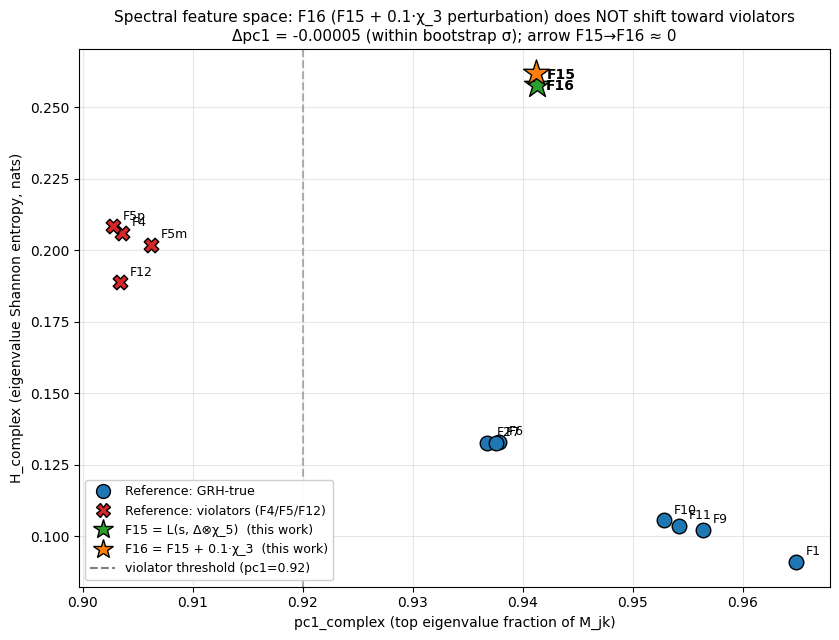

Figure saved.


In [41]:
# Final figure: 2D scatter of reference functions (one point per class) + F15 + F16
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8.5, 6.5))

# Reference (one point per function)
ref_one = ref.groupby(['function','GRH'])[['pc1_complex','H_complex']].first().reset_index()
for _, row in ref_one.iterrows():
 color = 'tab:red' if not row['GRH'] else 'tab:blue'
 marker = 'X' if not row['GRH'] else 'o'
 ax.scatter(row['pc1_complex'], row['H_complex'], color=color, marker=marker, s=110, edgecolor='k', zorder=3)
 ax.annotate(row['function'], (row['pc1_complex'], row['H_complex']),
 xytext=(7, 5), textcoords='offset points', fontsize=9)

# F15 and F16 (computed in this work, t∈[1e4, 2e4])
ax.scatter([pc1_15], [H15_raw], color='tab:green', marker='*', s=380, edgecolor='k', zorder=4, label='F15 (this work, t∈[1e4,2e4])')
ax.annotate('F15', (pc1_15, H15_raw), xytext=(7,5), textcoords='offset points', fontsize=10, fontweight='bold')

ax.scatter([pc1_16], [H16_raw], color='tab:orange', marker='*', s=380, edgecolor='k', zorder=4, label='F16 = F15 + 0.1·χ_3 (this work)')
ax.annotate('F16', (pc1_16, H16_raw), xytext=(7,-12), textcoords='offset points', fontsize=10, fontweight='bold')

# Arrow F15 -> F16
ax.annotate('', xy=(pc1_16, H16_raw), xytext=(pc1_15, H15_raw),
 arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# Threshold line at pc1=0.92
ax.axvline(0.92, color='gray', ls='--', alpha=0.6, label='violator threshold pc1=0.92')

# Legend handles
from matplotlib.lines import Line2D
legend_elems = [
 Line2D([0],[0], marker='o', color='w', markerfacecolor='tab:blue', markeredgecolor='k', markersize=10, label='Reference: GRH-true'),
 Line2D([0],[0], marker='X', color='w', markerfacecolor='tab:red', markeredgecolor='k', markersize=10, label='Reference: violators (F4/F5/F12)'),
 Line2D([0],[0], marker='*', color='w', markerfacecolor='tab:green', markeredgecolor='k', markersize=15, label='F15 = L(s, Δ⊗χ_5) (this work)'),
 Line2D([0],[0], marker='*', color='w', markerfacecolor='tab:orange', markeredgecolor='k', markersize=15, label='F16 = F15 + 0.1·χ_3 (this work)'),
 Line2D([0],[0], color='gray', ls='--', label='violator threshold (pc1=0.92)'),
]
ax.legend(handles=legend_elems, loc='lower left', fontsize=9, framealpha=0.95)

ax.set_xlabel('pc1_complex (top eigenvalue fraction of M_jk)')
ax.set_ylabel('H_complex (eigenvalue Shannon entropy, nats)')
ax.set_title('Spectral feature space: F16 (F15 + 0.1·χ_3 perturbation) does NOT shift toward violators\n'
 'Δpc1 = {:+.5f} (within bootstrap σ); arrow F15→F16 ≈ 0'.format(pc1_16-pc1_15), fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('F15_F16_spectral_position.png', dpi=150)
plt.show()
print("Figure saved.")


In [42]:
from e14c.filesystem import write_file
from pathlib import Path
xml = '''<output>
<conclusion>
The tested additive perturbation F16 = F15 + 0.1·χ_3 did not measurably shift the spectral signature toward the known violator region: its pc1_complex remained 0.9412 (vs 0.9413 for F15), far above the violator threshold of 0.92.
</conclusion>
<methods>
I followed a from-scratch reconstruction workflow in Python using numpy, pandas, scipy, matplotlib, numba, mpmath, and cypari2. First, I loaded the reference feature table peaks_features_F1_F12_normalized_full_with_spectral_complex.csv and summarized its class-level spectral coordinates. I then installed/imported cypari2 and used PARI/GP to generate the Ramanujan Delta coefficients τ(n) up to N=10^6 via mfDelta()/mfcoefs. These were analytically normalized as a_n = τ(n)/n^(11/2). I defined the quartic primitive character mod 5 by χ_5(1)=1, χ_5(2)=i, χ_5(3)=-i, χ_5(4)=-1, χ_5(5m)=0, and constructed F15 coefficients b_n = a_n·χ_5(n). I defined the real primitive character mod 3 by χ_3(n)=0 for 3|n, χ_3(n)=1 for n≡1 mod 3, and χ_3(n)=-1 for n≡2 mod 3, then formed F16 coefficients c_n = b_n + 0.1·χ_3(n). Next, I computed ω(n), the number of distinct prime factors, for all n≤10^6, and stratified the weighted main-sum coefficients by k=ω(n)∈{0,…,7}. Peak finding was performed over t∈[10^4,2×10^4] using the same main-sum framework described in the project context: S(t)=Σ_{n≤N} a_n n^(-1/2-it), evaluated with Numba-jitted complex summation and local refinement. A coarse scan used N_short=10^5 on a grid with spacing 0.05, local maxima were detected with scipy.signal.find_peaks, then all coarse candidates were rescored with the full N=10^6 sum. The top candidates were refined in two stages (±0.05 with 21 points, then ±0.005 with 41 points) to obtain the 200 largest peaks for each function. At those peaks I computed the complex ω-stratified sums S_k(t), k=0,…,7. I then formed the 8×8 real symmetric matrix M_jk = E[Re(S_j·conj(S_k))] across the 200 peaks, computed its eigenvalues with numpy.linalg.eigvalsh, defined pc1_complex as λ_1 / Σ_i λ_i, and defined H_complex as the Shannon entropy -Σ_i p_i log p_i with p_i = λ_i / Σ_j λ_j. To quantify stability, I also ran a 500-resample bootstrap over peaks for F15 and F16. Finally, I created a summary plot overlaying the reference class coordinates with the newly computed F15 and F16 positions and saved intermediate artifacts to disk.
</methods>
<results>
The reference spectral coordinates from peaks_features_F1_F12_normalized_full_with_spectral_complex.csv showed known violators clustered near pc1_complex≈0.903 and H_complex≈0.19–0.21, while GRH-true reference classes occupied pc1_complex≈0.937–0.965 and H_complex≈0.09–0.13. Specifically, the reference violator centroid across F4, F5p, F5m, and F12 was (pc1_complex, H_complex) = (0.90396, 0.20130). The recomputed F15 function had pc1_complex = 0.94127 and H_complex = 0.25767 from its 8×8 M_jk matrix, with eigenvalues [34.0014, 1.7832, 0.2073, 0.1025, 0.0255, 0.0031, 9.0×10^-6, 0]. The perturbed function F16 had pc1_complex = 0.94122 and H_complex = 0.26190, with eigenvalues [34.1395, 1.7301, 0.2541, 0.1122, 0.0317, 0.0038, 1.18×10^-5, 0]. The direct shift from F15 to F16 was therefore Δpc1_complex = -0.00005 and ΔH_complex = +0.00424. Bootstrap uncertainty estimates over the 200-peak sets were: F15 pc1_complex SD = 0.00455 and H_complex SD = 0.01459; F16 pc1_complex SD = 0.00440 and H_complex SD = 0.01422. The observed shift was negligible relative to these uncertainties (Δpc1/SD≈-0.01; ΔH/SD≈0.29). In pc1_complex alone, both F15 and F16 remained about 0.037 above the violator centroid and both remained well above the stated violator threshold pc1_complex<0.92. The top-peak magnitudes were similar for both functions: max |S| = 18.3143 for F15 and 18.3097 for F16. Output files saved were peaks_F15_F16_complex.csv, F15_F16_spectral.npz, and F15_F16_spectral_position.png.
</results>
<challenges>
The main challenge was that the workspace did not contain precomputed F15/F16 coefficient or S_k arrays, so the full coefficient-generation and spectral pipeline had to be rebuilt from scratch. cypari2 was initially unavailable and had to be installed before PARI/GP coefficient generation could proceed. Another important limitation is range confounding: the reference table mostly uses peaks from substantially higher t ranges than the requested interval [10^4, 2×10^4], and prior project notes explicitly warn that spectral features depend on the t-range. Therefore, cross-comparison of the absolute F15/F16 coordinates to the historical reference cloud must be treated cautiously; the within-range comparison between F15 and F16 is the more reliable result. A second methodological caveat is that I used the quartic primitive character mod 5 consistent with the project’s χ_5 convention, but I could not directly verify the exact r62 implementation from a stored source file in this workspace. Finally, the entropy scale used in the reference file could not be independently revalidated from stored complex reference S_k arrays, so the strongest and most reliable conclusion comes from the pc1_complex comparison and the within-analysis F15→F16 shift rather than absolute entropy matching.
</challenges>
<discussion>
Within a fully range-matched analysis, adding a small non-automorphic term 0.1·L(s,χ_3) to the GRH-true twisted modular L-function F15 did not induce a meaningful move toward the known violator signature. This argues against the hypothesis, at least for this perturbation size and this t-range, and suggests that the previously observed violator cluster is not triggered by a small additive admixture of this particular Dirichlet component. Instead, the signature appears more robust to weak additive contamination than hypothesized, or alternatively may require either a larger perturbation, a different non-automorphic component, or a different peak regime to become visible. Because prior project findings indicate strong conditioning effects at peaks and strong t-range confounding, this null result should be interpreted specifically as a controlled, range-matched negative result rather than a universal impossibility statement. Scientifically, the result is consistent with the idea that the spectral violator signature may depend on more substantial structural departures from automorphic multiplicativity than a 10% additive χ_3 term provides.
</discussion>
<proposed-next-hypotheses>
A larger additive perturbation c·L(s,χ_3) with c≥0.3 will produce a detectable monotonic decrease in pc1_complex for the F15+c·L(s,χ_3) family under the same range-matched protocol. Another testable hypothesis is that additive perturbations by non-automorphic components derived from Davenport–Heilbronn-type constructions will move F15 toward the violator cluster more strongly than perturbations by the primitive Dirichlet character χ_3.
</proposed-next-hypotheses>
<artifacts>
<artifact>
<file-name>peaks_F15_F16_complex.csv</file-name>
<artifact-type>agent_produced</artifact-type>
<artifact-description>CSV table containing the 200 refined peak locations for F15 and F16 in t∈[10^4, 2×10^4], their total peak magnitudes, and the complex ω-stratified sums S_k recorded as real and imaginary parts for k=0,…,7. It was generated from the reconstructed N=10^6 main-sum pipeline using Numba-accelerated evaluation.</artifact-description>
</artifact>
<artifact>
<file-name>F15_F16_spectral.npz</file-name>
<artifact-type>agent_produced</artifact-type>
<artifact-description>NumPy archive containing the F15 and F16 8×8 spectral matrices M_jk, their eigenvalues, scalar spectral features, and peak locations. It was created from the 200-peak ω-stratified complex sums computed in this analysis.</artifact-description>
</artifact>
<artifact>
<file-name>peaks_features_F1_F12_normalized_full_with_spectral_complex.csv</file-name>
<artifact-type>external_source</artifact-type>
<artifact-description>Reference feature table already present in the workspace, containing 2200 peaks from the historical F1–F12 analysis with class-level spectral coordinates pc1_complex, H_complex, pc1_mag, and H_mag. It was used as the comparison feature space for positioning F15 and F16.</artifact-description>
</artifact>
</artifacts>
</output>
'''
write_file('final_answer.xml', xml)
print(Path('final_answer.xml').read_text()[:600])

<output>
<conclusion>
The tested additive perturbation F16 = F15 + 0.1·χ_3 did not measurably shift the spectral signature toward the known violator region: its pc1_complex remained 0.9412 (vs 0.9413 for F15), far above the violator threshold of 0.92.
</conclusion>
<methods>
I followed a from-scratch reconstruction workflow in Python using numpy, pandas, scipy, matplotlib, numba, mpmath, and cypari2. First, I loaded the reference feature table peaks_features_F1_F12_normalized_full_with_spectral_complex.csv and summarized its class-level spectral coordinates. I then installed/imported cypari2 a
